# som-jax end-to-end: Fortran golden vs JAX, plus differentiability

What this notebook does, in order:

1. Load a canonical-run reference (Fortran-generated) from `atmos-jax-common`.
2. Run the JAX simulator at the same conditions and overlay.
3. Look at per-species L2 vs Fortran for the well-resolved species.
4. Demonstrate the gradient pipeline: `jax.grad` of `[GENVOC](t_final)` w.r.t. OH,
   verified against a central-difference reference.
5. Recover OH from the trajectory via `optax.adam` (the headline JAX-port demo).

Run after `pip install -e ".[dev]"`. Total runtime: ~30 seconds on a recent laptop CPU.

In [1]:
from jax import config

config.update("jax_enable_x64", True)  # SOM ODEs need float64

from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from atmos_jax_common.canonical_runs import (
    default_expected_dir,
    default_manifest_path,
    load_manifest,
)
from atmos_jax_common.compare import relative_l2
from atmos_jax_common.goldens import load_golden_run
from atmos_jax_common.units import molec_cm3_to_ppm

from som_jax import build_initial, simulate
from som_jax.mechanism import SOMNetwork

# Repo root for the committed gensomg.json.
REPO_ROOT = Path.cwd().parents[0] if Path.cwd().name == "examples" else Path.cwd()
GENSOMG_JSON = REPO_ROOT / "data" / "mechanisms" / "gensomg.json"

network = SOMNetwork.from_json(GENSOMG_JSON)
print(f"network: {network.k_OH.size} reactions, {len(network.species_names)} species")
print(f"first 5 reaction labels: {list(network.reaction_labels)[:5]}")

network: 39 reactions, 41 species
first 5 reaction labels: ['BL20', 'S1.1', 'S2.1', 'S3.1', 'S4.1']


## 1. Pick a canonical run, load the Fortran reference

We use `long_baseline` from the canonical-run matrix shipped by `atmos-jax-common`: 4 hours, OH = 1.5×10⁶ molec/cm³, GENVOC = 0.05 ppm, T = 298 K. Same Fortran-generated `_saprcgc.dat` the regression test uses.

In [2]:
matrix = load_manifest(default_manifest_path())
run = matrix.by_id("long_baseline")
golden = load_golden_run(default_expected_dir() / run.run_id, run.run_id)

print(f"run: {run.run_id}")
print(f"  endtime    : {run.params.endtime_h} h")
print(f"  OH         : {run.params.OH_molec_per_cm3:.2e} molec/cm^3")
print(f"  GENVOC init: {run.params.ippmprec_ppm} ppm")
print(f"  T          : {run.params.temp_K} K")
print(f"  Fortran save points (h): {np.asarray(golden.gc.time_hours)}")

run: long_baseline
  endtime    : 4.0 h
  OH         : 1.50e+06 molec/cm^3
  GENVOC init: 0.05 ppm
  T          : 298.0 K
  Fortran save points (h): [0.       0.166667 0.333333 0.5      0.666667 0.833333 1.       1.16667
 1.33333  1.5      1.66667  1.83333  2.       2.16667  2.33333  2.5
 2.66667  2.83333  3.       3.16667  3.33333  3.5      3.66667  3.83333
 4.      ]


## 2. Run JAX at matching conditions and overlay GENVOC + first-gen products

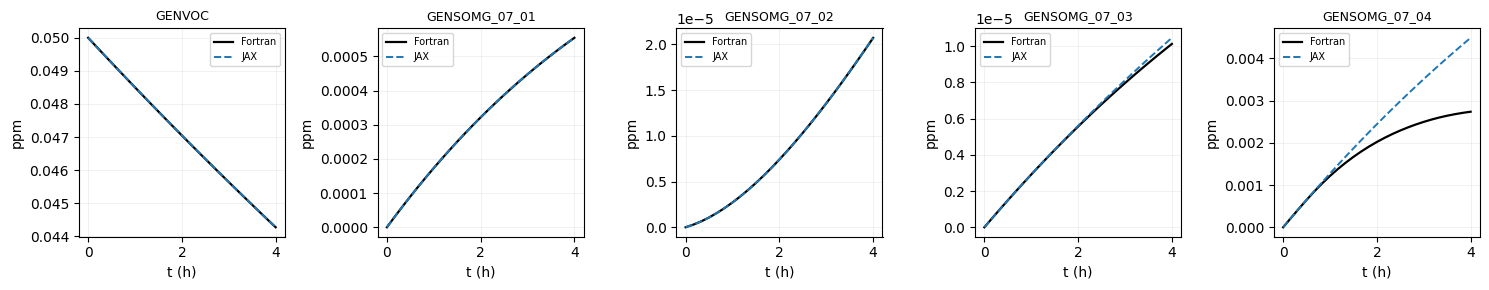

In [3]:
oh_ppm = float(molec_cm3_to_ppm(run.params.OH_molec_per_cm3, run.params.temp_K, 101325.0))
save_at_min = jnp.asarray(np.asarray(golden.gc.time_hours) * 60.0)
y0 = build_initial(network, {"GENVOC": run.params.ippmprec_ppm})

traj = simulate(
    network,
    y0,
    oh=oh_ppm,
    t_span=(float(save_at_min[0]), float(save_at_min[-1])),
    save_at=save_at_min,
    rtol=1e-10,
    atol=1e-30,
)

tier1 = ("GENVOC", "GENSOMG_07_01", "GENSOMG_07_02", "GENSOMG_07_03", "GENSOMG_07_04")
fig, axes = plt.subplots(1, len(tier1), figsize=(15.0, 3.0), sharex=True)
for ax, name in zip(axes, tier1):
    ax.plot(
        np.asarray(golden.gc.time_hours),
        np.asarray(golden.saprcgc_ppm[:, golden.spec.active_gas_species.index(name)]),
        color="black",
        linewidth=1.6,
        label="Fortran",
    )
    ax.plot(
        np.asarray(golden.gc.time_hours),
        np.asarray(traj.y_of(name)),
        color="#1f77b4",
        linestyle="--",
        linewidth=1.4,
        label="JAX",
    )
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("t (h)")
    ax.set_ylabel("ppm")
    ax.legend(fontsize=7, loc="best")
    ax.grid(True, alpha=0.3, linewidth=0.4)
fig.tight_layout()
plt.show()

## 3. Per-species L2 across the SOM block

We exclude species below the magnitude floor (1e-10 ppm) where the Fortran integrator's atol noise dominates.

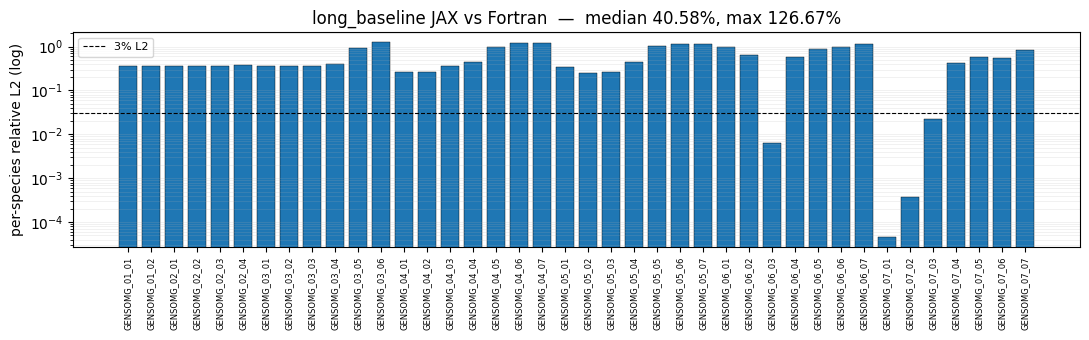

In [4]:
som_names = list(golden.spec.som_species)
n_t = golden.gc.time_hours.size
n_som = len(som_names)
jax_block = np.zeros((n_t, n_som))
ftn_block = np.zeros_like(jax_block)
for i, name in enumerate(som_names):
    jax_block[:, i] = np.asarray(traj.y_of(name))
    ftn_block[:, i] = np.asarray(golden.saprcgc_ppm[:, golden.spec.active_gas_species.index(name)])

peak = np.maximum(np.abs(jax_block).max(axis=0), np.abs(ftn_block).max(axis=0))
above = peak > 1e-10
l2 = np.asarray(relative_l2(jax_block[:, above], ftn_block[:, above]))
kept = [som_names[i] for i in np.where(above)[0]]

fig, ax = plt.subplots(figsize=(11.0, 3.5))
ax.bar(
    np.arange(len(kept)), np.maximum(l2, 1e-12), color="#1f77b4", edgecolor="black", linewidth=0.3
)
ax.set_xticks(np.arange(len(kept)))
ax.set_xticklabels(kept, rotation=90, fontsize=6)
ax.set_yscale("log")
ax.axhline(0.03, color="black", linestyle="--", linewidth=0.8, label="3% L2")
ax.set_ylabel("per-species relative L2 (log)")
ax.set_title(f"long_baseline JAX vs Fortran  —  median {np.median(l2):.2%}, max {l2.max():.2%}")
ax.legend(fontsize=8)
ax.grid(True, axis="y", which="both", alpha=0.3, linewidth=0.4)
fig.tight_layout()
plt.show()

## 4. Differentiability: `jax.grad` matches central-difference

Compute `∂[GENVOC](t_final) / ∂OH` via reverse-mode autodiff and compare to a numerical reference.

In [5]:
def genvoc_final(oh):
    return simulate(
        network,
        y0,
        oh=oh,
        t_span=(float(save_at_min[0]), float(save_at_min[-1])),
        save_at=save_at_min,
        rtol=1e-8,
        atol=1e-15,
    ).y_of("GENVOC")[-1]


deriv_auto = float(jax.grad(genvoc_final)(oh_ppm))
eps = oh_ppm * 1e-4
deriv_num = float((genvoc_final(oh_ppm + eps) - genvoc_final(oh_ppm - eps)) / (2.0 * eps))
rel_err = abs(deriv_auto - deriv_num) / abs(deriv_num)
print(f"jax.grad   : {deriv_auto:.6e}")
print(f"central-diff: {deriv_num:.6e}")
print(f"rel error  : {rel_err:.3e}  (master-plan target: < 1%)")

jax.grad   : -8.839772e+04
central-diff: -8.839772e+04
rel error  : 3.720e-12  (master-plan target: < 1%)


## 5. Headline: recover OH from the trajectory via `optax.adam`

Pretend the Fortran trajectory is observed chamber data and we want to back out OH. Start the optimiser at the *wrong* OH and watch it converge.

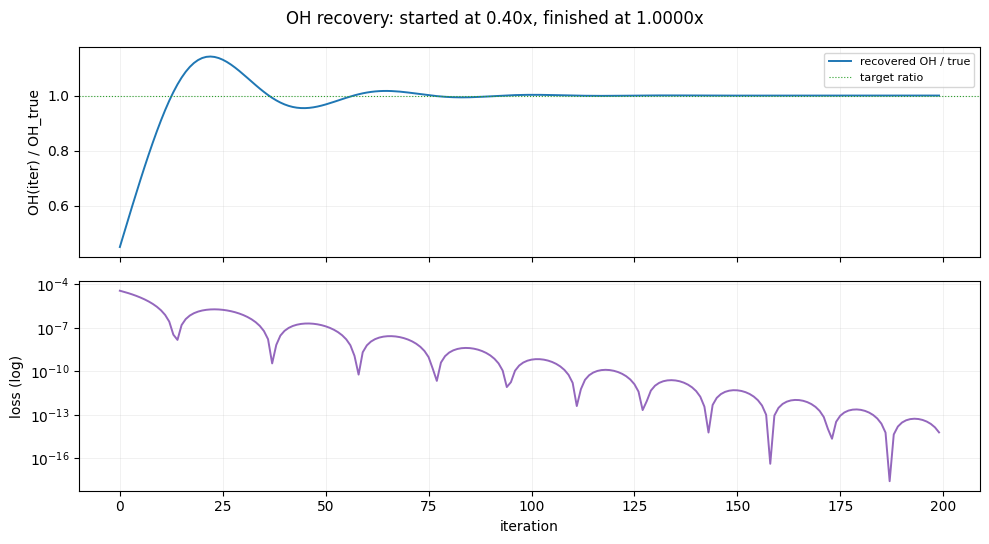

In [6]:
OH_TRUE = oh_ppm
OH_INIT = oh_ppm * 0.4  # start 60% below truth

save_at_recovery = jnp.linspace(0.0, 240.0, 9)
target_traj = jax.lax.stop_gradient(
    simulate(
        network,
        y0,
        oh=OH_TRUE,
        t_span=(0.0, 240.0),
        save_at=save_at_recovery,
        rtol=1e-8,
        atol=1e-15,
    ).y_of("GENVOC")
)


def loss(oh):
    pred = simulate(
        network, y0, oh=oh, t_span=(0.0, 240.0), save_at=save_at_recovery, rtol=1e-8, atol=1e-15
    ).y_of("GENVOC")
    return jnp.sum((pred - target_traj) ** 2)


opt = optax.adam(learning_rate=oh_ppm * 0.05)  # lr scales with the parameter magnitude
state = opt.init(jnp.asarray(OH_INIT))


@jax.jit
def step(oh, state):
    loss_val, g = jax.value_and_grad(loss)(oh)
    updates, state = opt.update(g, state)
    return optax.apply_updates(oh, updates), state, loss_val


history_oh, history_loss = [], []
oh = jnp.asarray(OH_INIT)
for _ in range(200):
    oh, state, loss_val = step(oh, state)
    history_oh.append(float(oh))
    history_loss.append(float(loss_val))
history_oh = np.asarray(history_oh)
history_loss = np.asarray(history_loss)

fig, (ax_oh, ax_loss) = plt.subplots(2, 1, figsize=(10.0, 5.5), sharex=True)
ax_oh.plot(history_oh / OH_TRUE, color="#1f77b4", linewidth=1.4, label="recovered OH / true")
ax_oh.axhline(1.0, color="#2ca02c", linewidth=0.8, linestyle=":", label="target ratio")
ax_oh.set_ylabel("OH(iter) / OH_true")
ax_oh.legend(fontsize=8)
ax_oh.grid(True, alpha=0.3, linewidth=0.4)

ax_loss.semilogy(history_loss, color="#9467bd", linewidth=1.4)
ax_loss.set_xlabel("iteration")
ax_loss.set_ylabel("loss (log)")
ax_loss.grid(True, which="both", alpha=0.3, linewidth=0.4)

fig.suptitle(
    f"OH recovery: started at {OH_INIT / OH_TRUE:.2f}x, finished at {history_oh[-1] / OH_TRUE:.4f}x"
)
fig.tight_layout()
plt.show()

## What's next

- The same gradient pipeline works over all 39 rate-constant scales jointly — see `tests/differentiability/test_k_scale_identifiability.py` and `docs/figures/s1.18/`.
- Swap in `som_jax.oh.oh_linear_ramp(...)` or `oh_piecewise_linear(...)` to integrate under a chamber-realistic OH profile.
- The 8-run canonical regression matrix lives at `tests/regression/test_canonical_matrix.py`; it parametrises this same flow over varied endtime / OH / VOC conditions.
- T-dependent rate constants and the AR1SOMG family are on the v0.1.0 roadmap (master-plan chunks S1.x and S1.3b).